In [5]:
#!pip install music21
!apt-get install -y lilypond

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lmodern fonts-noto-mono fonts-urw-base35
  ghostscript libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0
  libkpathsea6 libptexenc1 libsynctex2 libteckit0 libtexlua53 libtexluajit2
  libwoff1 libzzip-0-13 lilypond-data lilypond-fonts lmodern poppler-data
  t1utils tex-common texlive-base texlive-binaries texlive-latex-base
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x lilypond-doc python3-lxml poppler-utils fonts-japanese-mincho
  | fonts-ipafont-mincho fonts-japanese-gothic | fonts-ipafont-gothic
  fonts-arphic-ukai fonts-arphic-uming fonts-nanum debhelper perl-tk xpdf
  | pdf-viewer xzdec texlive-latex-base-doc
The following NEW packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lmodern fonts-n

In [6]:
#Importing Libraries
import tensorflow as tf
import numpy as np
import pandas as pd
from collections import Counter
import random
import IPython
from IPython.display import Image, Audio
import music21
from music21 import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.saving import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adamax
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
import sys
import os
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

#import lilypond
#import subprocess
SEED = 616


In [7]:
np.random.seed(SEED)

In [8]:
!unzip classical-music-midi.zip;

Archive:  classical-music-midi.zip
  inflating: albeniz/alb_esp1.mid    
  inflating: albeniz/alb_esp2.mid    
  inflating: albeniz/alb_esp3.mid    
  inflating: albeniz/alb_esp4.mid    
  inflating: albeniz/alb_esp5.mid    
  inflating: albeniz/alb_esp6.mid    
  inflating: albeniz/alb_se1.mid     
  inflating: albeniz/alb_se2.mid     
  inflating: albeniz/alb_se3.mid     
  inflating: albeniz/alb_se4.mid     
  inflating: albeniz/alb_se5.mid     
  inflating: albeniz/alb_se6.mid     
  inflating: albeniz/alb_se7.mid     
  inflating: albeniz/alb_se8.mid     
  inflating: bach/bach_846.mid       
  inflating: bach/bach_847.mid       
  inflating: bach/bach_850.mid       
  inflating: balakir/islamei.mid     
  inflating: beeth/appass_1.mid      
  inflating: beeth/appass_2.mid      
  inflating: beeth/appass_3.mid      
  inflating: beeth/beethoven_hammerklavier_1.mid  
  inflating: beeth/beethoven_hammerklavier_2.mid  
  inflating: beeth/beethoven_hammerklavier_3.mid  
  inflating: b

In [121]:
#Loading the list of chopin's midi files as stream
filepath = "chopin/"
#Getting midi files
all_midis= []
for i in os.listdir(filepath):
    if i.endswith(".mid"):
        tr = filepath+i
        midi = converter.parse(tr)
        all_midis.append(midi)

In [122]:
#Helping function
def extract_notes(file):
    notes = []
    pick = None
    for j in file:
        songs = instrument.partitionByInstrument(j)
        for part in songs.parts:
            pick = part.recurse()
            for element in pick:
                if isinstance(element, note.Note):
                    notes.append(str(element.pitch))
                elif isinstance(element, chord.Chord):
                    notes.append(".".join(str(n) for n in element.normalOrder))

    return notes
#Getting the list of notes as Corpus
Corpus= extract_notes(all_midis)
print("Total notes in all the Chopin midis in the dataset:", len(Corpus))

Total notes in all the Chopin midis in the dataset: 57886


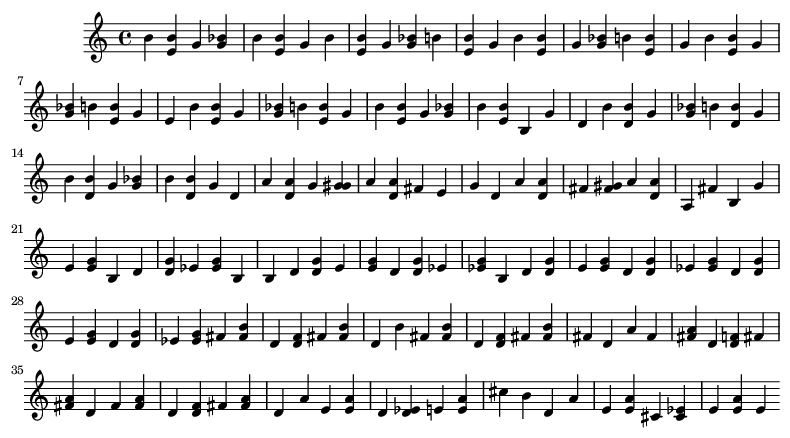

In [123]:
#First Lets write some functions that we need to look into the data
def show(music):
    display(Image(str(music.write("lily.png"))))

def note_sheet(Snippet):
    Melody = []
    offset = 0 #Incremental
    for i in Snippet:
        #If it is chord
        if ("." in i or i.isdigit()):
            chord_notes = i.split(".") #Seperating the notes in chord
            notes = []
            for j in chord_notes:
                inst_note=int(j)
                note_snip = note.Note(inst_note)
                notes.append(note_snip)
                chord_snip = chord.Chord(notes)
                chord_snip.offset = offset
                Melody.append(chord_snip)
        # pattern is a note
        else:
            note_snip = note.Note(i)
            note_snip.offset = offset
            Melody.append(note_snip)
        # increase offset each iteration so that notes do not stack
        offset += 1
    Melody_midi = stream.Stream(Melody)
    return Melody_midi

Melody_Snippet = note_sheet(Corpus[:100])
show(Melody_Snippet)

In [124]:
#to play audio or corpus

print("Sample Audio From Data")
#IPython.display.Audio("../input/music-generated-lstm/Corpus_Snippet.wav", rate=20000)

Sample Audio From Data


In [125]:
#Creating a count dictionary
count_num = Counter(Corpus)
print("Total unique notes in the Corpus:", len(count_num))

Total unique notes in the Corpus: 397


In [126]:
#Exploring the notes dictionary
Notes = list(count_num.keys())
Recurrence = list(count_num.values())
#Average recurrenc for a note in Corpus
def Average(lst):
    return sum(lst) / len(lst)
print("Average recurrence for a note in Corpus:", Average(Recurrence))
print("Most frequent note in Corpus appeared:", max(Recurrence), "times")
print("Least frequent note in Corpus appeared:", min(Recurrence), "time")
print("Mean frequency of notes in Corpus is:", np.mean(Recurrence), "time")
print("Median frequency of notes in Corpus is:", np.median(Recurrence), "time")

Average recurrence for a note in Corpus: 145.80856423173805
Most frequent note in Corpus appeared: 1627 times
Least frequent note in Corpus appeared: 1 time
Mean frequency of notes in Corpus is: 145.80856423173805 time
Median frequency of notes in Corpus is: 23.0 time


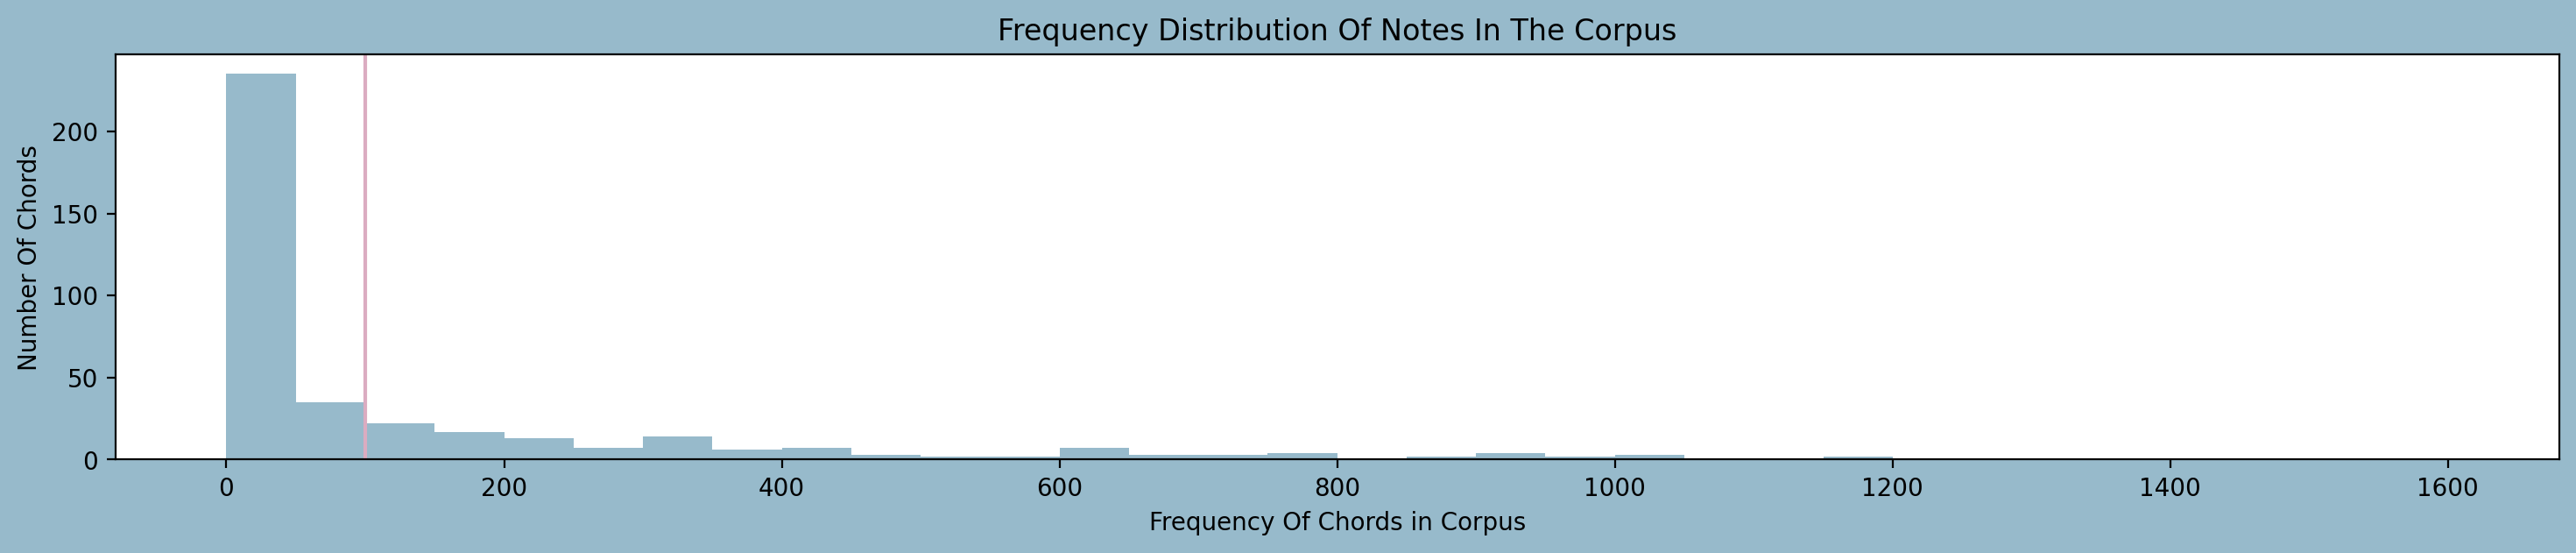

In [127]:
# Plotting the distribution of Notes
plt.figure(figsize=(18,3),facecolor="#97BACB")
bins = np.arange(0,(max(Recurrence)), 50)
plt.hist(Recurrence, bins=bins, color="#97BACB")
plt.axvline(x=100,color="#DBACC1")
plt.title("Frequency Distribution Of Notes In The Corpus")
plt.xlabel("Frequency Of Chords in Corpus")
plt.ylabel("Number Of Chords")
plt.show()

In [135]:
#Getting a list of rare chords
rare_note = []
for index, (key, value) in enumerate(count_num.items()):
    if value < np.median(Recurrence):
        m = key
        rare_note.append(m)

print(f"Total number of notes that occur less than {np.median(Recurrence)} times:", len(rare_note))

Total number of notes that occur less than 23.0 times: 200


In [136]:
#Eleminating the rare notes
for element in Corpus:
    if element in rare_note:
        Corpus.remove(element)

print("Length of Corpus after elemination the rare notes:", len(Corpus))

Length of Corpus after elemination the rare notes: 56879


In [137]:
# Storing all the unique characters present in my corpus to bult a mapping dic.
symb = sorted(list(set(Corpus)))

L_corpus = len(Corpus) #length of corpus
L_symb = len(symb) #length of total unique characters

#Building dictionary to access the vocabulary from indices and vice versa
mapping = dict((c, i) for i, c in enumerate(symb))
reverse_mapping = dict((i, c) for i, c in enumerate(symb))

print("Total number of characters:", L_corpus)
print("Number of unique characters:", L_symb)

Total number of characters: 56879
Number of unique characters: 201


In [138]:
#Splitting the Corpus in equal length of strings and output target
length = 40
features = []
targets = []
for i in range(0, L_corpus - length, 1):
    feature = Corpus[i:i + length]
    target = Corpus[i + length]
    features.append([mapping[j] for j in feature])
    targets.append(mapping[target])


L_datapoints = len(targets)
print("Total number of sequences in the Corpus:", L_datapoints)

Total number of sequences in the Corpus: 56839


In [139]:
# reshape X and normalize
X = (np.reshape(features, (L_datapoints, length, 1)))/ float(L_symb)
# one hot encode the output variable
y = tf.keras.utils.to_categorical(targets)

In [140]:
X.shape

(56839, 40, 1)

In [141]:
y.shape

(56839, 201)

In [142]:
#Taking out a subset of data to be used as seed
X_train, X_seed, y_train, y_seed = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Model Keras

In [157]:
#Initialising the Model
modelk = Sequential()
#Adding layers
modelk.add(LSTM(512, input_shape=(X.shape[1], X.shape[2]), return_sequences=True))
modelk.add(Dropout(0.1))
modelk.add(LSTM(256))
modelk.add(Dense(256))
modelk.add(Dropout(0.1))
modelk.add(Dense(y.shape[1], activation='softmax'))
#Compiling the model for training
opt = Adamax(learning_rate=0.001)
modelk.compile(loss='categorical_crossentropy', optimizer=opt)

In [158]:
#Model's Summary
modelk.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 40, 512)        │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 40, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 256)            │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 201)            │        51,657 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,957,577 (7.47 MB)

 Trainable params: 1,957,577 (7.47 MB)

 Non-trainable params: 0 (0.00 B)

In [159]:
from google.colab import drive
drive.mount('/content/drive')
path = "drive/MyDrive/"

Mounted at /content/drive


In [161]:
#Training the Model
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath= '/training_checkpoints/mozart/ckpt_{epoch}.weights.h5',  # Change name for author on whoms midis you trained
        save_weights_only=True),
    #tf.keras.callbacks.EarlyStopping(
        #monitor='loss',
        #min_delta=0.001,
        #patience=10,
        #verbose=1,
        #restore_best_weights=True),
]
EPOCHS = 250
history = modelk.fit(X_train, y_train, batch_size=256, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/250
178/178 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 4.8171
Epoch 2/250
 87/178 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 4.6301

KeyboardInterrupt: 

In [ ]:
model.save(path + "midigen_Mozart.keras")  # Change name for author on whoms midis you trained

In [170]:
#Plotting the learnings
history_df = pd.DataFrame(history.history)
fig = plt.figure(figsize=(15,4), facecolor="#97BACB")
fig.suptitle("Learning Plot of Model for Loss")
pl=sns.lineplot(data=history_df["loss"],color="#444160")
pl.set(ylabel ="Training Loss")
pl.set(xlabel ="Epochs")

NameError: name 'history' is not defined

# Generation

In [181]:
# Melody generation function for Keras model
def Melody_Generator_keras(Note_Count, temp=1.0):
    seed = X_seed[np.random.randint(0,len(X_seed)-1)]
    Music = ""
    Notes_Generated=[]
    for i in range(Note_Count):
        seed = seed.reshape(1,length,1)
        prediction = modelk.predict(seed, verbose=0)[0]
        print(prediction)
        prediction = np.log(prediction) / temp #diversity
        print(prediction)
        exp_preds = np.exp(prediction)
        prediction = exp_preds / np.sum(exp_preds) #tf.nn.softmax(predictions)#
        index = np.argmax(prediction)
        index_N = index/ float(L_symb)
        Notes_Generated.append(index)
        Music = [reverse_mapping[char] for char in Notes_Generated]
        seed = np.insert(seed[0], len(seed[0]), index_N)
        seed = seed[1:]
    # Now, we have music in form or a list of chords and notes and we want to be a midi file.
    Melody = note_sheet(Music)
    Melody_midi = stream.Stream(Melody)
    return Music, Melody_midi



[4.5706707e-04 2.5869667e-04 3.9147693e-04 3.4411802e-05 5.0984841e-04
 2.8209708e-04 4.5284905e-04 1.4876144e-04 4.5808271e-04 7.6341435e-05
 9.8685377e-05 5.3823466e-04 3.3274302e-04 4.3791396e-04 1.9168355e-04
 9.4912824e-04 1.3177245e-04 5.0784351e-04 1.2025855e-04 7.5714983e-04
 8.3536509e-04 8.3722291e-05 4.1324121e-04 3.5129470e-04 3.3950046e-04
 5.8027456e-04 4.9186969e-05 5.7248209e-05 3.5930198e-04 1.4847187e-04
 1.4837662e-04 1.8643460e-04 1.7234187e-04 5.2395742e-04 4.4071555e-04
 3.9000859e-04 1.2432103e-04 7.4224512e-04 6.4596965e-04 3.8173632e-05
 3.8061212e-04 4.6589569e-04 3.3748100e-04 1.4200249e-04 5.8144948e-04
 3.8273365e-04 2.5196758e-04 7.3446956e-04 2.1462954e-04 3.3656065e-04
 1.9317625e-04 1.9510082e-04 5.8175315e-04 7.5625145e-04 3.0853334e-04
 4.4036855e-04 1.7441387e-04 2.7210021e-04 1.5187614e-04 8.7880908e-04
 1.7911279e-04 9.4601179e-05 1.7706658e-04 7.1546249e-04 6.3728477e-04
 4.2942350e-04 1.9775380e-04 2.6125181e-04 2.1752370e-04 2.2111225e-04
 1.699

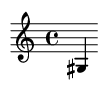

In [182]:
#getting the Notes and Melody created by the model
Music_notes, Melody = Melody_Generator_keras(1)
show(Melody)

In [32]:
#To save the generated melody
Melody.write('midi','Melody_Generated.mid')
#to play audio or corpus
#IPython.display.Audio("../Melody_Generated 2.wav", rate=20000)

'Melody_Generated.mid'

# Saving/loading model instruments

In [143]:
#Initialising the Model
modelk = Sequential()
#Adding layers
modelk.add(LSTM(512, input_shape=(X.shape[1], X.shape[2]), return_sequences=True))
modelk.add(Dropout(0.1))
modelk.add(LSTM(256))
modelk.add(Dense(256))
modelk.add(Dropout(0.1))
modelk.add(Dense(y.shape[1], activation='softmax'))
#Compiling the model for training
opt = Adamax(learning_rate=0.001)
modelk.compile(loss='categorical_crossentropy', optimizer=opt)



In [147]:
# Loads the weights
#modelk.load_weights(f"ckpt_{220}.weights.h5")




In [27]:
modelk.save("midigen_Chopin.keras")

In [145]:
modelk = load_model("midigen_Chopin.keras")

## ЕБАНЫЙ МУСОР БЛЯТЬ (ДАЖЕ НЕ СМОТРИТЕ)


In [187]:
import torch
import torch.nn as nn
import torch.optim as optim

class LSTMMIDI(nn.Module):
    def __init__(self, input_size, output_size,hidden_size_1=512, hidden_size_2=256, dropout_rate=0.1):
        super(LSTMMIDI, self).__init__()

        # LSTM layers
        self.lstm1 = nn.LSTM(input_size, hidden_size_1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.lstm2 = nn.LSTM(hidden_size_1, hidden_size_2, batch_first=True)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size_2, 256)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, output_size)

        # Softmax activation
        self.softmax = nn.Softmax()  # For sequence output

    def forward(self, x):
        # First LSTM layer
        lstm1_out, (h1, c1) = self.lstm1(x)
        lstm1_out = self.dropout1(lstm1_out)

        # Second LSTM layer
        # Note: In your Keras model, return_sequences=False for the second LSTM
        # So we take only the last output
        lstm2_out, (h2, c2) = self.lstm2(lstm1_out)

        # Take the last time step output (when not using return_sequences)
        # This matches your Keras model where second LSTM doesn't return sequences
        lstm2_last = lstm2_out[:, -1, :]

        # Fully connected layers
        fc1_out = self.fc1(lstm2_last)
        fc1_out = self.dropout2(fc1_out)
        fc2_out = self.fc2(fc1_out)

        # Apply softmax to output
        output = self.softmax(fc2_out)

        return output






In [188]:
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm  # For progress bars
import matplotlib.pyplot as plt


# Assuming X and y are your numpy arrays from preprocessing
# Convert numpy arrays to PyTorch tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(np.argmax(y, axis=1))  # Convert one-hot to class indices for CrossEntropyLoss

# Create dataset and dataloader
dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=256, shuffle=True)

# Initialize model
input_size = X.shape[2]
output_size = y.shape[1]  # Number of classes

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = LSTMMIDI(
    input_size=input_size,
    output_size=output_size,
    hidden_size_1=512,
    hidden_size_2=256,
    dropout_rate=0.1
).to(device)

# Define optimizer and loss function
optimizer = optim.Adamax(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training parameters
num_epochs = 250
total_batches = len(train_loader)

# For tracking metrics
train_losses = []
train_accuracies = []

def calculate_accuracy(outputs, targets):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == targets).sum().item()
    return correct / targets.size(0)

# Training loop
print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_accuracy = 0.0

    # Progress bar for batches
    batch_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)

    for batch_idx, (inputs, targets) in enumerate(batch_pbar):
        # Move data to device
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()

        # Optional: Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Calculate accuracy
        accuracy = calculate_accuracy(outputs, targets)

        # Update metrics
        epoch_loss += loss.item()
        epoch_accuracy += accuracy

        # Update progress bar
        batch_pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{accuracy:.4f}'
        })

    # Calculate epoch averages
    avg_loss = epoch_loss / len(train_loader)
    avg_accuracy = epoch_accuracy / len(train_loader)

    train_losses.append(avg_loss)
    train_accuracies.append(avg_accuracy)

    # Print epoch summary
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Loss: {avg_loss:.4f}, '
          f'Accuracy: {avg_accuracy:.4f}')

    # Optional: Save checkpoint every 50 epochs
    if (epoch + 1) % 50 == 0:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'accuracy': avg_accuracy
        }
        torch.save(checkpoint, f'model_checkpoint_epoch_{epoch+1}.pth')
        print(f"Checkpoint saved at epoch {epoch+1}")

# Save final model
final_model_path = 'midi_generation_model_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'input_size': input_size,
    'output_size': output_size,
    'hidden_size_1': 512,
    'hidden_size_2': 256,
    'dropout_rate': 0.1,
    'epochs': num_epochs,
    'loss': train_losses[-1],
    'accuracy': train_accuracies[-1]
}, final_model_path)
print(f"\nFinal model saved to {final_model_path}")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(train_losses, label='Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accuracies, label='Training Accuracy', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTraining completed!")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.4f}")

Using device: cuda
Starting training...


Epoch [1/250], Loss: 5.2900, Accuracy: 0.0226


KeyboardInterrupt: 

In [ ]:
def predict(model, X, batch_size=32, device=None):
    """
    PyTorch version of Keras-like predict function
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
    model.eval()  # Set to evaluation mode

    # Convert to tensor if needed
    if not isinstance(X, torch.Tensor):
        X = torch.FloatTensor(X)

    dataset = torch.utils.data.TensorDataset(X)
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    all_predictions = []

    with torch.no_grad():  # Disable gradient computation
        inputs = X.to(device)
        outputs = model(inputs)
        all_predictions.append(outputs.cpu().numpy())

    # Concatenate all batches
    return np.vstack(all_predictions)

# Usage
predictions = predict(model, X_seed[np.random.randint(0,len(X_seed)-1)].reshape(1,length,1))
predictions

In [191]:
def Melody_Generator(Note_Count):
    seed = X_seed[0]#[np.random.randint(0,len(X_seed)-1)]
    Music = ""
    Notes_Generated=[]
    for i in range(Note_Count):
        seed = seed.reshape(1, length, 1)
        model.eval()  # Set to evaluation mode
        with torch.no_grad():  # No gradient computation
            inputs = torch.FloatTensor(seed).to(device)
            outputs = model(inputs)
            prediction = outputs.cpu().numpy()

        prediction = prediction.flatten()
        prediction = np.log(prediction) / 1.0 #diversity
        #exp_preds = np.exp(prediction)
        prediction = nn.Softmax(prediction)
        index = np.argmax(prediction)
        index_N = index/ float(L_symb)
        #print(index_N)
        Notes_Generated.append(index)
        Music = [reverse_mapping[char] for char in Notes_Generated]
        seed = np.insert(seed[0],len(seed[0]),index_N)
        seed = seed[1:]
    # Now, we have music in form or a list of chords and notes and we want to be a midi file.
    Melody = note_sheet(Music)
    Melody_midi = stream.Stream(Melody)
    return Music, Melody_midi


In [193]:
Music_notes, Melody = Melody_Generator(1)
show(Melody)

UnboundLocalError: cannot access local variable 'prediction' where it is not associated with a value